In [97]:
import numpy as np
import matplotlib.pyplot as plt
import kcorrect
from astropy.table import Table
import pandas as pd
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM
#from dustmaps.sfd import SFDQuery

In [98]:
#kcorrect?

In [99]:
#import healpy

In [100]:
from dustmaps.config import config
config.reset()

In [101]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [102]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Custom bandpasses

## F140W (JH gap) reprocess

In [103]:
F140W_rep = False

if F140W_rep == True:
    
    # Read bandpass
    bp_F140W = np.loadtxt('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/HST_images/wfcam_JH.dat')
    wav_F140W = np.round(bp_F140W[:,0],1)
    resp_F140W = bp_F140W[:,1]    
    
    # Make table
    t = Table([wav_F140W,resp_F140W],
               names=('lambda', 'pass'))
    
    # Save in fixed width format
    t.write('/opt/anaconda3/lib/python3.9/site-packages/kcorrect/data/responses/wfcam_JH.dat', 
            format='ascii.fixed_width', overwrite=True) 

## MUSE write

In [104]:
wav0_MUSE = 4751.284541786687 # In Å
dwav_MUSE = 1.25
N_pix_MUSE = 3681

wav_MUSE = np.arange(wav0_MUSE, wav0_MUSE+N_pix_MUSE*dwav_MUSE, dwav_MUSE)

In [105]:
# Define this for automation later
bandpasses_MUSE = {'pseudo_g': [4800,5800], 'pseudo_r': [6000,7500], 'pseudo_i': [7500,9000]}

In [106]:
MUSE_write = False

if MUSE_write == True:
    for k in list(bandpasses_MUSE.keys()):

        # Get wavelength limits
        wav_lims = bandpasses_MUSE[k]

        # Read in MUSE response
        df = pd.read_csv('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/MUSE/MUSE_bp.csv')
        df.columns = ['lambda','pass']
        # Edge effects
        wav_arr = 10*np.array([485,490] + list(df['lambda']) + [900,905]) # To Å
        pass_arr = np.array([0,29.808658] + list(df['pass']) + [25.065098,0])/100 # To fraction

        # Fix negatives
        pass_arr[pass_arr<=0] = 0
        
        # Interpolate along uniform wavelength array
        pass_interp = interp1d(wav_arr, pass_arr, fill_value=0, bounds_error=False)(wav_MUSE)

        # Isolate relevant wavelengths
        wav_idx = (wav_MUSE<wav_lims[0])|(wav_MUSE>wav_lims[1])
        # Create bandpass
        pass_interp[wav_idx] = 0 # Set bandpass not in filter


        # Save bandpass
        # Make table
        wav_idx_save = (wav_MUSE>=wav_lims[0]-15*dwav_MUSE)&(wav_MUSE<=wav_lims[1]+15*dwav_MUSE)
        t = Table([wav_MUSE[wav_idx_save],pass_interp[wav_idx_save]],
                   names=('lambda', 'pass'))

        plt.plot(wav_MUSE[wav_idx_save], pass_interp[wav_idx_save])

        # Save in fixed width format
        t.write('/opt/anaconda3/lib/python3.9/site-packages/kcorrect/data/responses/muse_{}.dat'.format(k), 
                format='ascii.fixed_width', overwrite=True) 

# Utilities

Some definitions for HST

In [107]:
# Calibration for F140W
PHOTFNU_F140W = 9.5432426E-08
t_exp_F140W = 555.875916

# Calibration for F160W 
PHOTFNU_F160W = 1.5308434e-07
t_exp_F160W = 227.93692 # seconds

# Calibration and pivot wavelength for F814W
PHOTPLAM_F814W = 8045.5352
PHOTFLAM_F814W = 7.092805575e-20
# F_nu sensitivity calculation using pivot wavelength and F_lam sensitivity
# Formula presumably converts F_lam in erg/s/Å to F_nu in Jy
PHOTFNU_814W = 3.34e+4*PHOTPLAM_F814W**2*PHOTFLAM_F814W
t_exp_F814W = 546.0

# Make global dictionaries
PHOTFNU_dict = {'F140W':PHOTFNU_F140W, 'F160W':PHOTFNU_F160W, 'F814W':PHOTFNU_814W}
t_exp_dict = {'F140W':t_exp_F140W, 'F160W':t_exp_F160W, 'F814W':t_exp_F814W}

In [108]:
# Magnitude -> Janskys -> e/s -> e -> sqrt(e) -> err/s -> d(Jansky) -> dm = -(2.5/ln(10))*d(Jansky)/Jansky

Function to compute HST photometric error

In [109]:
def compute_phot_err(mags):
    
    '''
    mags: list of AB magnitudes
    '''
    
    F_nu_Jy_arr = 3631*10**(-0.4*mags) # In Jy
    
    dmags = np.zeros(len(mags))
    
    for i in range(len(PHOTFNU_dict)):
        
        filt = list(PHOTFNU_dict.keys())[i]
        F_nu_Jy = F_nu_Jy_arr[i]

        count_rate = F_nu_Jy/PHOTFNU_dict[filt] # Divide by sensitivity
        counts = count_rate*t_exp_dict[filt] # Get counts

        counts_err = np.sqrt(counts) # Get count error assuming Poisson counting
        count_rate_err = counts_err/t_exp_dict[filt] # Divide counts by exposure time
        dF_nu_Jy = count_rate_err*PHOTFNU_dict[filt] # Get error in F_nu

        # Compute error in magnitude using propagation of error
        dmags[i] = np.abs((-2.5/np.log(10))*(dF_nu_Jy/F_nu_Jy))    
    
    return np.round(dmags,3)

All bandpasses

In [110]:
wavs_pass_min = np.array([4800,6000,7500,6800,11370,14210])
wavs_pass_max = np.array([5800,7500,9000,10000,16450,19240])

wavs_pass_cen = .5*(wavs_pass_max+wavs_pass_min)
dwavs_pass = .5*(wavs_pass_max-wavs_pass_min)

Extinction scaled to E(B-V)=1

In [111]:
ext_scale = np.array([3.255, 2.446, 1.758, 1.743, 0.754, 0.556])

Functions for maggies and ivar

In [112]:
def get_maggies(m):
    # Maggies
    mu = 10**(-0.4*m)
    return mu

In [113]:
def get_ivar_maggies(mu, dm):
    dmu = np.abs(-0.4*np.log(10)*dm*mu)
    # Inverse variance for maggies
    return dmu**-2

Functions for Mstar

In [114]:
def get_Mstar_15(Mr, Mg):
    
    if Mg-Mr<0.15:
        ML = -0.6
    else:
        ML = -1.01 + 2.95*(Mg-Mr) - 1.67*(Mg-Mr)**2
    
    return 1.872 - 0.4*Mr + ML

In [115]:
def get_Mstar_24(MB, ug):
    
    if ug<0.9:
        return -0.36*MB + 2.17*ug + 1.1
    else:
        return -0.36*MB + 0.72*ug + 2.4

## z=0.0966

In [793]:
redshift = 0.0966
ebv = 0.0397

In [794]:
MUSE_mags = np.array([24.653, 24.175, 24.145])
dMUSE_mags = np.array([0.003, 0.002, 0.004])

HST_mags = np.array([23.803,22.883,22.655])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [795]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [796]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [54]:
responses_out = ['sdss_r0', 'sdss_g0',]
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

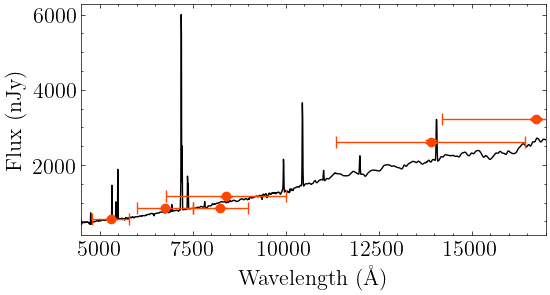

In [55]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [58]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [59]:
np.round(Mstar_KC,1)

7.4

In [56]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [57]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-14.08, -13.55, 7.6)

### Q24

In [797]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [798]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [62]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

In [63]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [64]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-13.43, 0.75, 7.6)

## z=0.1203

In [799]:
redshift = 0.1203
ebv = 0.0397

In [800]:
MUSE_mags = np.array([18.85872, 18.12838, 17.69731])
dMUSE_mags = np.array([1e-5, 1e-5, 1e-5])

HST_mags = np.array([18.03,16.898,16.789])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [801]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [802]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [542]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

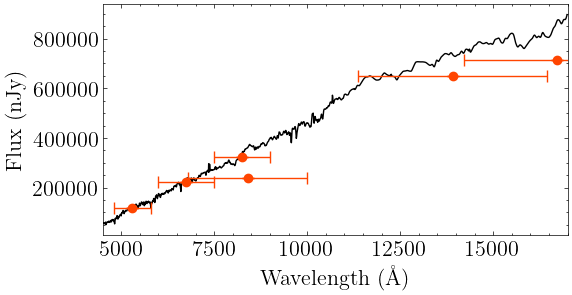

In [543]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [544]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [545]:
np.round(Mstar_KC,1)

10.4

In [546]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [547]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.65, -19.81, 10.4)

### Q24

In [803]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [804]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [550]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

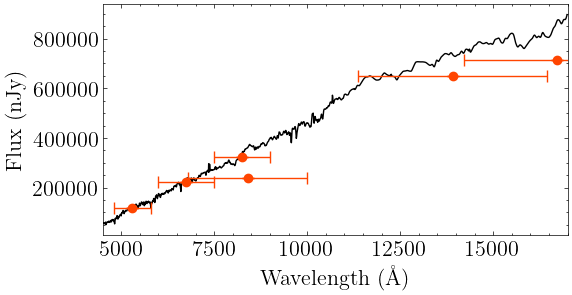

In [551]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [552]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [553]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.47, 1.75, 10.7)

## z=0.1204

In [805]:
redshift = 0.1204
ebv = 0.0397

In [806]:
MUSE_mags = np.array([20.06678, 19.5231, 19.20591])
dMUSE_mags = np.array([4e-05, 2e-05, 4e-05])

HST_mags = np.array([19.784,18.48,18.369])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [807]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [808]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [574]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

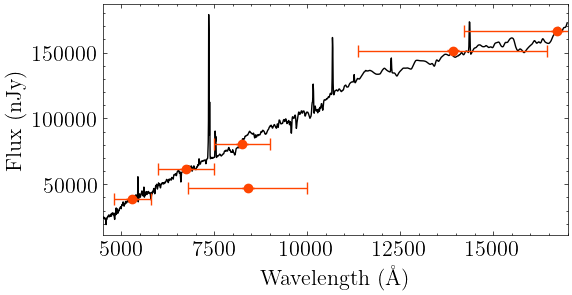

In [575]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [576]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [577]:
np.round(Mstar_KC,1)

9.7

In [578]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [579]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.25, -18.62, 9.8)

### Q24

In [809]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [810]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [582]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

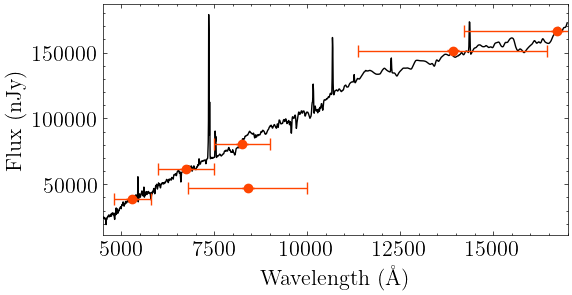

In [583]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [584]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [585]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.39, 1.35, 10.0)

## z=0.1393

In [811]:
redshift = 0.1393
ebv = 0.0397

In [812]:
MUSE_mags = np.array([24.134, 23.889, 23.58])
dMUSE_mags = np.array([0.003, 0.003, 0.005])

HST_mags = np.array([23.797,22.784,22.655])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [813]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [814]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [85]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

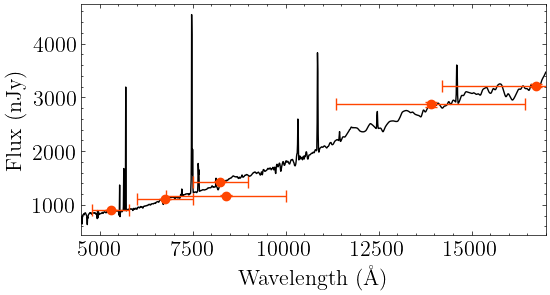

In [86]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [87]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [88]:
np.round(Mstar_KC,1)

7.9

In [89]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [90]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.23, -14.93, 7.7)

### Q24

In [815]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [816]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [93]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

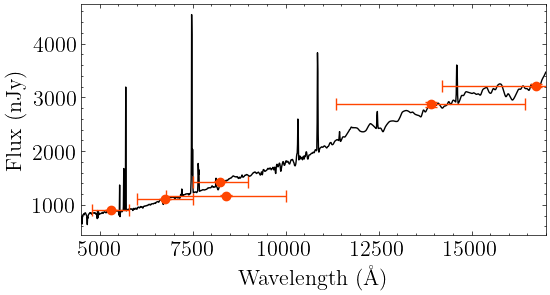

In [94]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [95]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [96]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-14.86, 0.46, 7.4)

## z=0.2791

In [817]:
redshift = 0.2791
ebv = 0.0404

In [818]:
MUSE_mags = np.array([25.698, 25.247, 25.11])
dMUSE_mags = np.array([0.006, 0.004, 0.01])

HST_mags = np.array([25.864, 23.432, 23.282])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [819]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [820]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r


In [75]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

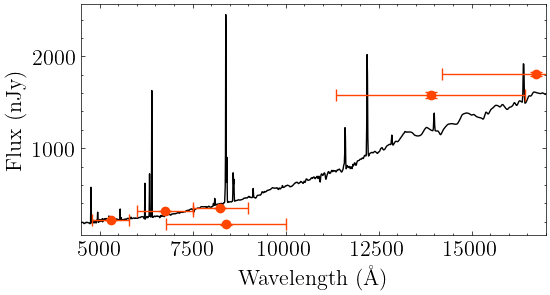

In [76]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [87]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [88]:
np.round(Mstar_KC,1)

8.3

In [79]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [80]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-14.75, -14.28, 7.8)

### Q24

In [821]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [822]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [83]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

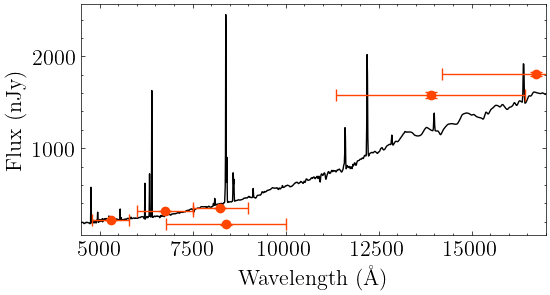

In [84]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [85]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [86]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-15.0, 0.43, 7.4)

## z=0.2915

In [823]:
redshift = 0.2915
ebv = 0.0404

In [824]:
MUSE_mags = np.array([26.49, 26.15, 25.5])
dMUSE_mags = np.array([0.01, 0.01, 0.01])

HST_mags = np.array([25.755, 23.838, 23.676])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [825]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [826]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r


In [232]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

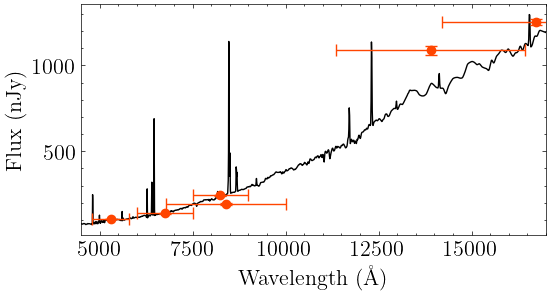

In [233]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [234]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [235]:
np.round(Mstar_KC,1)

8.2

In [236]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [237]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-14.97, -14.35, 8.0)

### Q24

In [827]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [828]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [240]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

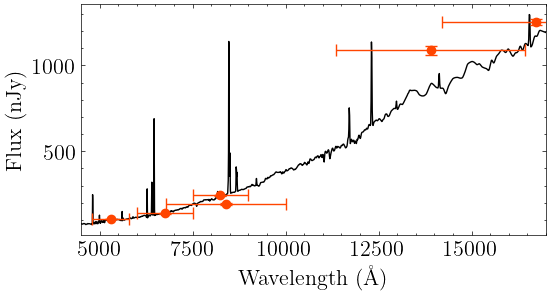

In [241]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [242]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [243]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-14.36, 0.31, 6.9)

## z=0.3198

In [829]:
redshift = 0.3198
ebv = 0.0404

In [830]:
MUSE_mags = np.array([24.01, 23.434, 23.126])
dMUSE_mags = np.array([0.001, 0.001, 0.002])

HST_mags = np.array([23.027,21.89,21.746])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [831]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [832]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [293]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

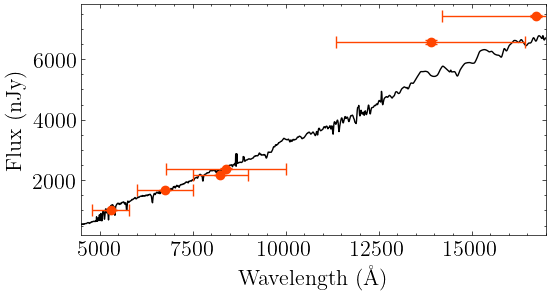

In [294]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [295]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [296]:
np.round(Mstar_KC,1)

9.1

In [297]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [298]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.75, -17.33, 8.9)

### Q24

In [833]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [834]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [301]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

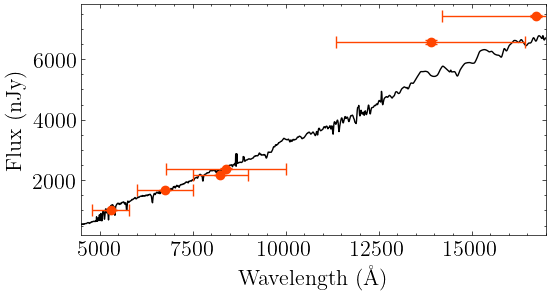

In [302]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [303]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [304]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.16, 0.94, 9.3)

## z=0.3752

In [835]:
redshift = 0.3752
ebv = 0.0404

In [836]:
MUSE_mags = np.array([24.899, 24.147, 23.981])
dMUSE_mags = np.array([0.003, 0.002, 0.003])

HST_mags = np.array([24.418, 22.834, 22.624])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [837]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [838]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [358]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

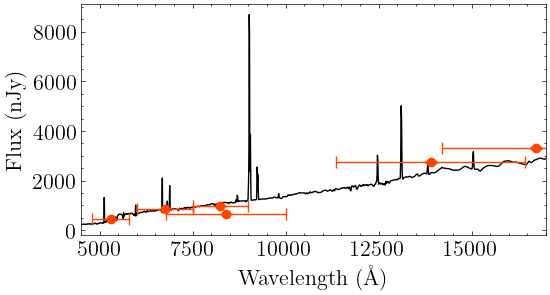

In [359]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [360]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [361]:
np.round(Mstar_KC,1)

8.8

In [362]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [363]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.44, -17.05, 8.7)

### Q24

In [839]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [840]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [366]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

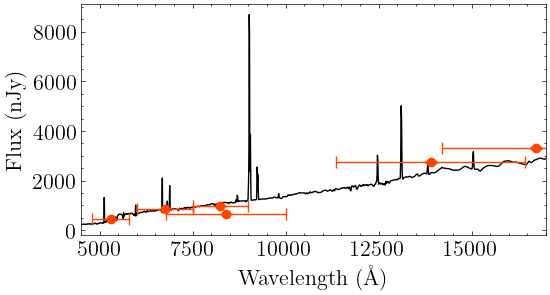

In [367]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [368]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [369]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-16.91, 1.11, 9.3)

## z=0.3759

In [841]:
redshift = 0.3759
ebv = 0.0397

In [842]:
MUSE_mags = np.array([26.92, 25.776, 25.46])
dMUSE_mags = np.array([0.02, 0.008, 0.02])

HST_mags = np.array([25.077,23.472,23.441])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [843]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [844]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [408]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

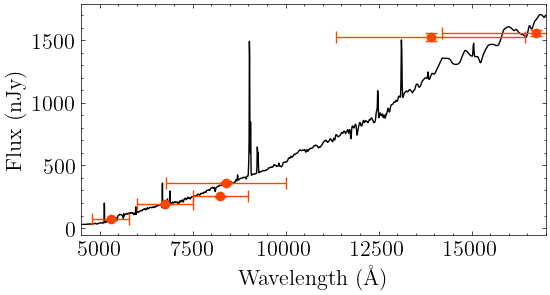

In [409]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [410]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [411]:
np.round(Mstar_KC,1)

8.6

In [412]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [413]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.96, -15.36, 8.4)

### Q24

In [845]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [846]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [416]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

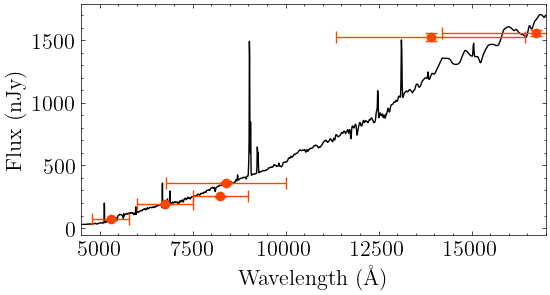

In [417]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [418]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [419]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-15.1, 1.58, 9.0)

## z=0.4395

In [848]:
redshift = 0.4395
ebv = 0.0404

In [849]:
MUSE_mags = np.array([25.477, 24.215, 23.703])
dMUSE_mags = np.array([0.006, 0.002, 0.003])

HST_mags = np.array([23.55, 22.146, 22.313])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [850]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [851]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [392]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

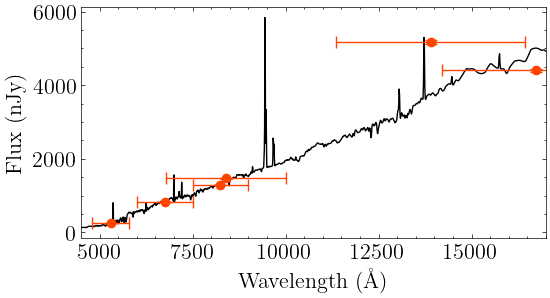

In [393]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [394]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [395]:
np.round(Mstar_KC,1)

9.3

In [396]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [397]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-18.15, -17.41, 9.4)

### Q24

In [852]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [853]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [400]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

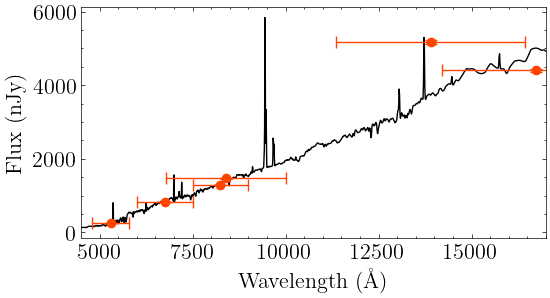

In [401]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [402]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [403]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.16, 1.43, 9.6)

## z=0.4581

In [854]:
redshift = 0.4581
ebv = 0.0404

In [855]:
MUSE_mags = np.array([23.1248, 22.4526, 22.3413])
dMUSE_mags = np.array([0.0006, 0.0004, 0.0008])

HST_mags = np.array([22.217,21.346,21.363])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [856]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [857]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [429]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

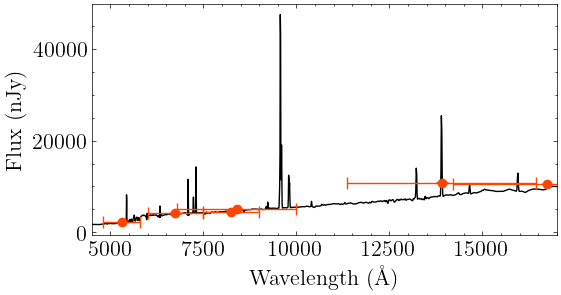

In [430]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [431]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [432]:
np.round(Mstar_KC,1)

9.5

In [433]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [434]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.6, -19.27, 9.5)

### Q24

In [858]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [859]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [437]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

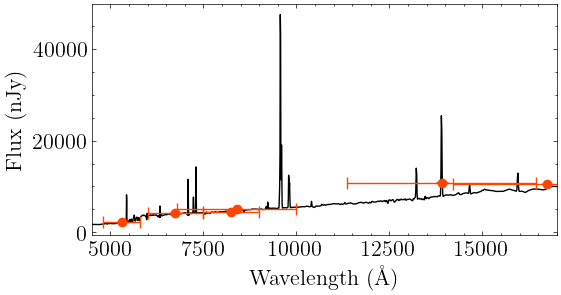

In [438]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [439]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [440]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.17, 0.72, 9.6)

## z=0.4784

In [1002]:
redshift = 0.4784
ebv = 0.0397

In [1003]:
MUSE_mags = np.array([23.957, 23.166, 22.579])
dMUSE_mags = np.array([0.003, 0.001, 0.002])

HST_mags = np.array([23.194,21.987,21.776])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [1004]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [1005]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [1006]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

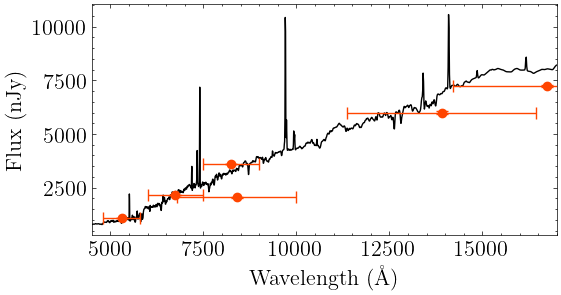

In [1007]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1008]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [1009]:
np.round(Mstar_KC,1)

9.8

In [1010]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [1011]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.45, -18.71, 9.9)

### Q24

In [1012]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [1013]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [1014]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

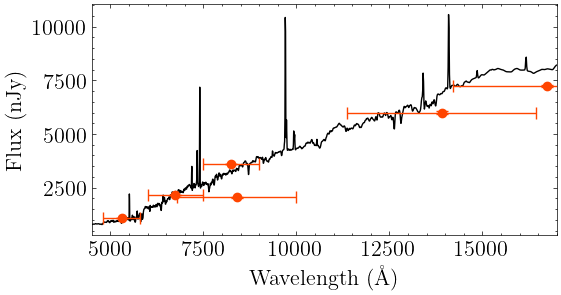

In [1015]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1016]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [1017]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.48, 0.83, 9.6)

## z=0.5191

In [876]:
redshift = 0.5191
ebv = 0.0404

In [877]:
MUSE_mags = np.array([25.3, 23.807, 23.279])
dMUSE_mags = np.array([0.004, 0.001, 0.002])

HST_mags = np.array([23.149,21.69,21.535])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [878]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [879]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [495]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

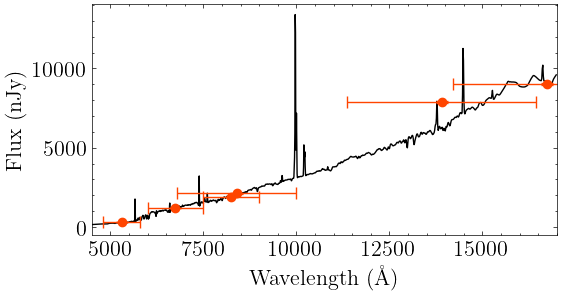

In [496]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [497]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [498]:
np.round(Mstar_KC,1)

9.7

In [499]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [500]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.15, -18.35, 9.8)

### Q24

In [880]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [881]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [503]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

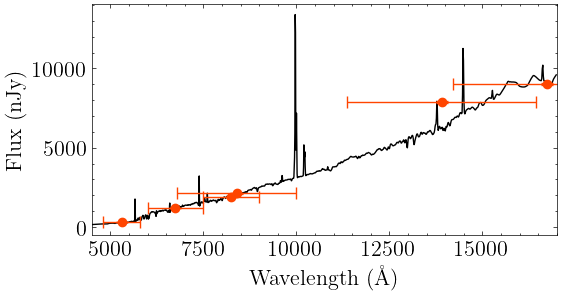

In [504]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [505]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [507]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.12, 1.51, 10.0)

## z=0.5205

In [882]:
redshift = 0.5205
ebv = 0.0404

In [883]:
MUSE_mags = np.array([23.893, 22.791, 22.334])
dMUSE_mags = np.array([0.001, 0.001, 0.001])

HST_mags = np.array([22.342,21.384,21.272])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [884]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [885]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [514]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

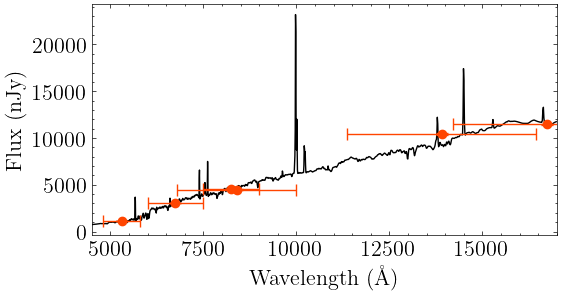

In [515]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [516]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [517]:
np.round(Mstar_KC,1)

10.0

In [518]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [519]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.95, -19.36, 10.0)

### Q24

In [886]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [888]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [522]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

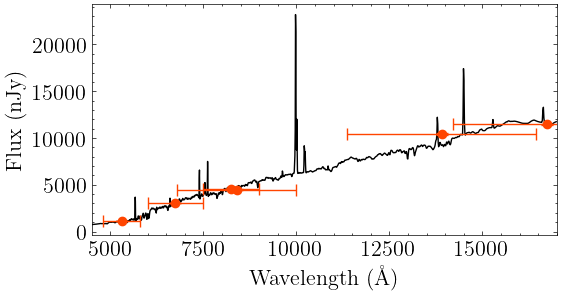

In [526]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [527]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [528]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.15, 1.16, 10.1)

## z=0.5356

In [889]:
redshift = 0.5356
ebv = 0.0404

In [890]:
MUSE_mags = np.array([22.9101, 21.6208, 21.0552])
dMUSE_mags = np.array([0.0005, 0.0002, 0.0002])

HST_mags = np.array([21.132, 20.225, 20.069])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [891]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [892]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [607]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

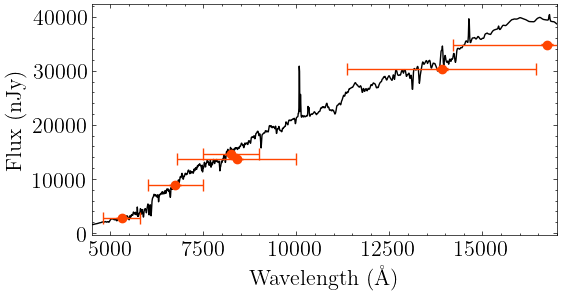

In [608]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [609]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [610]:
np.round(Mstar_KC,1)

10.6

In [611]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [612]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.3, -20.66, 10.6)

### Q24

In [893]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [894]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [615]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

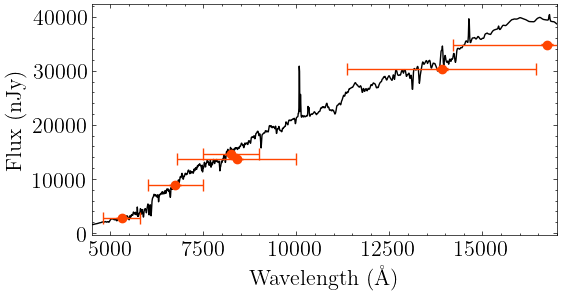

In [616]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [619]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [620]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.41, 1.37, 10.7)

## z=0.5723

In [1018]:
redshift = 0.5723
ebv = 0.0397

In [1019]:
MUSE_mags = np.array([23.858, 22.26, 21.5364])
dMUSE_mags = np.array([0.001, 0.0003, 0.0004])

HST_mags = np.array([21.719, 20.567, 20.415])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [1020]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [1021]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [1022]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

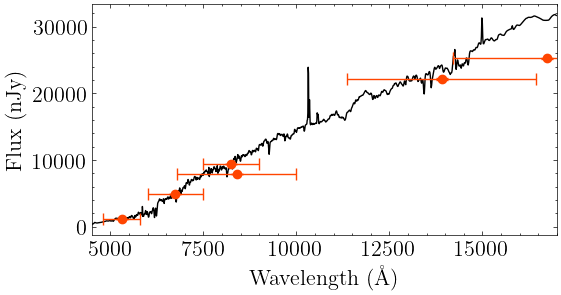

In [1023]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1024]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [1025]:
np.round(Mstar_KC,1)

10.6

In [1026]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [1027]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.07, -20.22, 10.6)

### Q24

In [1028]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [1029]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [1030]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

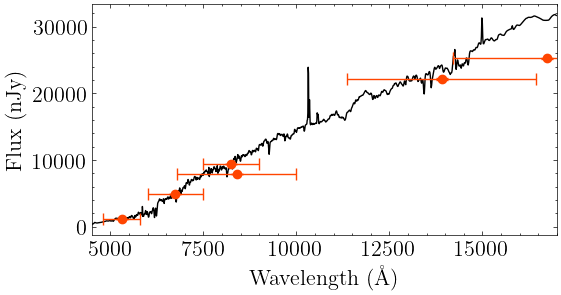

In [1031]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1032]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [1033]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.04, 1.59, 10.8)

## z=0.6174

In [901]:
redshift = 0.6174
ebv = 0.0404

In [902]:
MUSE_mags = np.array([26.51, 25.625, 25.15])
dMUSE_mags = np.array([0.01,  0.007, 0.01])

HST_mags = np.array([25.294, 23.433, 23.254])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [903]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [904]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [644]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

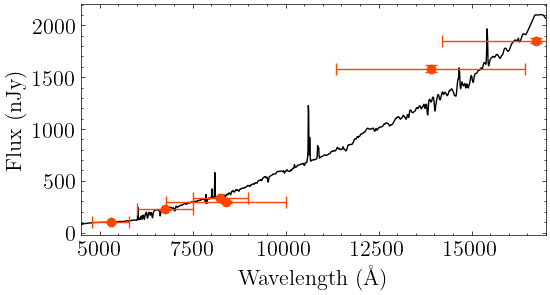

In [645]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [646]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [647]:
np.round(Mstar_KC,1)

9.2

In [648]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [649]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.79, -16.95, 9.3)

### Q24

In [905]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [906]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [652]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

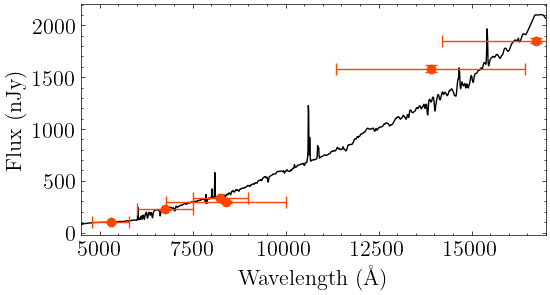

In [653]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [654]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [655]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-16.91, 0.87, 9.1)

## z=0.6178

In [907]:
redshift = 0.6178
ebv = 0.0404

In [908]:
MUSE_mags = np.array([23.852, 23.0267, 22.789])
dMUSE_mags = np.array([0.001, 0.0006, 0.001])

HST_mags = np.array([22.839,22.519,22.357])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [909]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [910]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [677]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

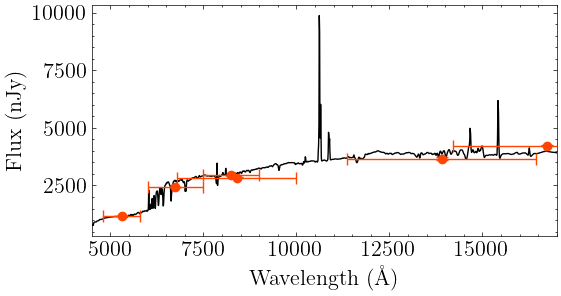

In [678]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [679]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [680]:
np.round(Mstar_KC,1)

9.2

In [681]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [682]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.76, -19.48, 9.5)

### Q24

In [911]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [912]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [685]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

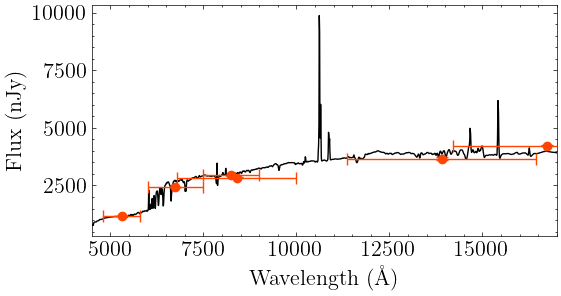

In [686]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [691]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [692]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.45, 0.74, 9.7)

## z=0.6183

In [913]:
redshift = 0.6183
ebv = 0.0404

In [914]:
MUSE_mags = np.array([24.419, 23.835, 23.141])
dMUSE_mags = np.array([0.002, 0.001, 0.002])

HST_mags = np.array([23.222, 22.613, 22.531])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [915]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [916]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [709]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

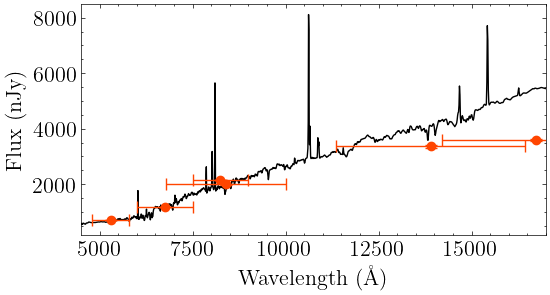

In [710]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [711]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [712]:
np.round(Mstar_KC,1)

9.9

In [713]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [714]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.6, -19.04, 9.8)

### Q24

In [917]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [918]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [717]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

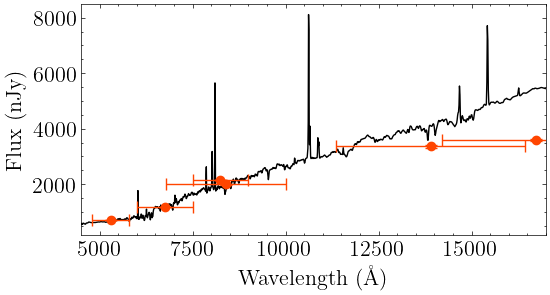

In [718]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [721]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [722]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.71, 0.91, 9.8)

## z=0.6469

In [919]:
redshift = 0.6469
ebv = 0.0397

In [920]:
MUSE_mags = np.array([26.6, 25.624, 25.11])
dMUSE_mags = np.array([0.01, 0.006, 0.01])

HST_mags = np.array([25.688, 23.091, 22.944])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [921]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [922]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [728]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

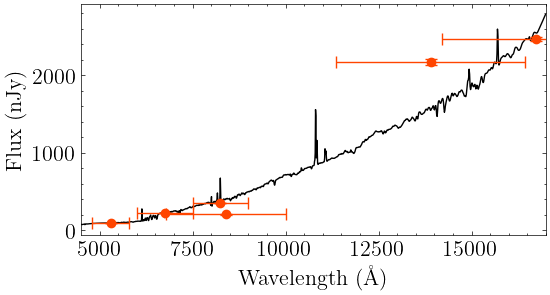

In [729]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [730]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [731]:
np.round(Mstar_KC,1)

9.4

In [732]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [733]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-18.07, -16.69, 9.0)

### Q24

In [923]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [924]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [736]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

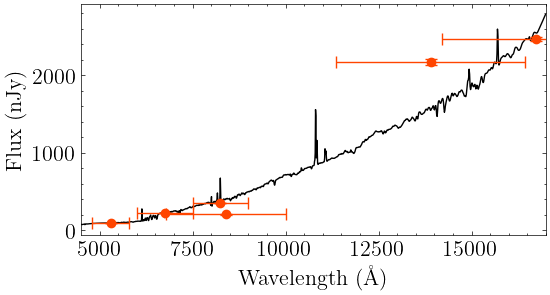

In [737]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [738]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [739]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.12, 0.56, 8.5)

## z=0.6531

In [925]:
redshift = 0.6531
ebv = 0.0397

In [926]:
MUSE_mags = np.array([25.162, 24.289, 24.048])
dMUSE_mags = np.array([0.004, 0.002, 0.004])

HST_mags = np.array([24.187, 22.697, 22.483])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [927]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [928]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [745]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

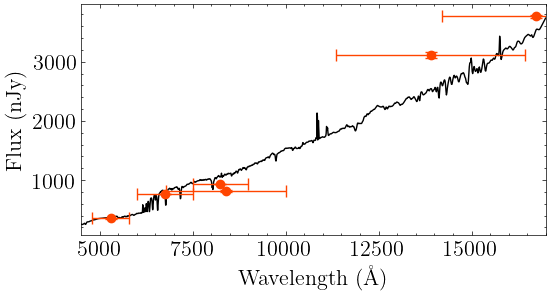

In [746]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [747]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [748]:
np.round(Mstar_KC,1)

9.5

In [749]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [750]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-18.86, -18.26, 9.6)

### Q24

In [929]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [931]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [753]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

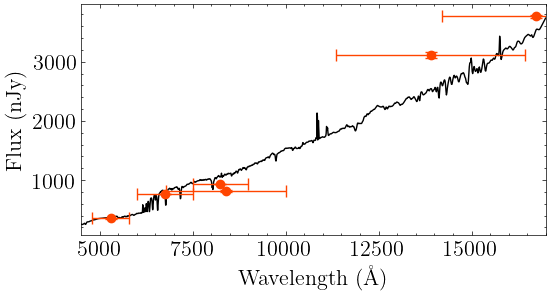

In [754]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [755]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [756]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.41, 0.69, 9.2)

## z=0.6780

In [961]:
redshift = 0.6780
ebv = 0.0404

In [962]:
MUSE_mags = np.array([25.629, 24.152, 23.813])
dMUSE_mags = np.array([0.008, 0.002, 0.005])

HST_mags = np.array([23.634,22.512,22.415])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [963]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [964]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [936]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

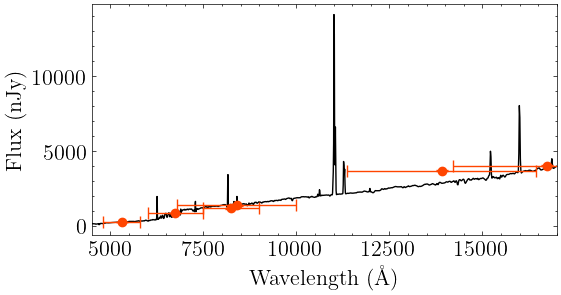

In [937]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [938]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [939]:
np.round(Mstar_KC,1)

9.5

In [940]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [941]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.22, -18.92, 9.3)

### Q24

In [965]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [966]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_g
wfpc2_f814w


In [967]:
dresp_lams

array([[ 2251.   ,   801.   ,   699.   ,   589.   ,  6449.   ,  8449.   ],
       [  645.154,   804.846,  2304.846,  2194.846,  8054.846, 10054.846],
       [ 2704.06 ,  1254.06 ,   245.94 ,   135.94 ,  5995.94 ,  7995.94 ]])

In [944]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

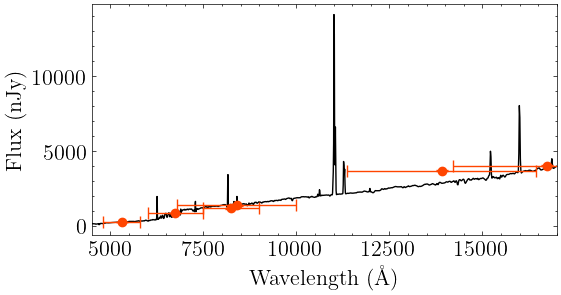

In [945]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [946]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [947]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.76, 1.4, 10.2)

## z=0.7010

In [985]:
redshift = 0.7010
ebv = 0.0397

In [986]:
MUSE_mags = np.array([24.894, 23.984, 23.326])
dMUSE_mags = np.array([0.003, 0.001, 0.002])

HST_mags = np.array([23.335, 21.244, 21.078])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [987]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [988]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [989]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

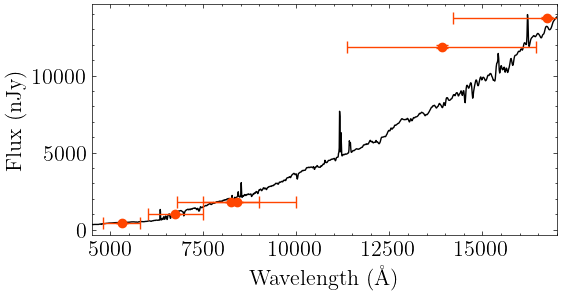

In [990]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [991]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [992]:
np.round(Mstar_KC,1)

10.2

In [993]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [994]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.13, -19.33, 10.2)

### Q24

In [995]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [996]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r
wfpc2_f814w


In [997]:
dresp_lams

array([[2354.5  ,  904.5  ,  595.5  ,  485.5  , 6345.5  , 8345.5  ],
       [ 726.643,  723.357, 2223.357, 2113.357, 7973.357, 9973.357],
       [2813.77 , 1363.77 ,  136.23 ,   26.23 , 5886.23 , 7886.23 ]])

In [998]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

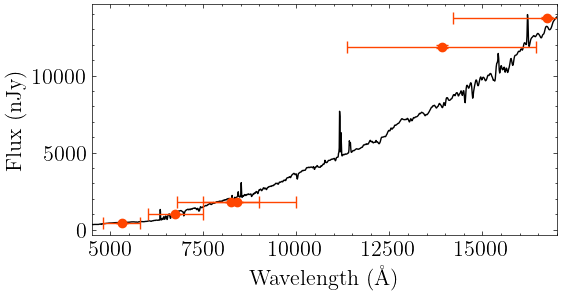

In [999]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1000]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [1001]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.08, 1.18, 10.1)

## z=0.7293

In [1034]:
redshift = 0.7293
ebv = 0.0397

In [1035]:
MUSE_mags = np.array([23.75, 22.8725, 22.4264])
dMUSE_mags = np.array([0.001, 0.0005, 0.0008])

HST_mags = np.array([22.33, 21.577, 21.419])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [1036]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [1037]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_i


In [1038]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

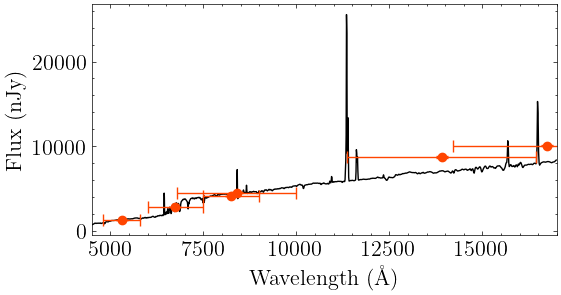

In [1039]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1040]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [1041]:
np.round(Mstar_KC,1)

9.8

In [1042]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [1043]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.65, -20.28, 10.0)

### Q24

In [1046]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [1047]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r
muse_pseudo_i


In [1048]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

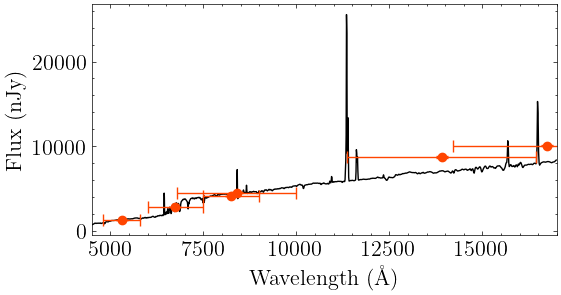

In [1049]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1050]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [1051]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.31, 0.86, 10.3)

## z=0.8217

In [1052]:
redshift = 0.8217
ebv = 0.0404

In [1053]:
MUSE_mags = np.array([25.051, 24.085, 23.297])
dMUSE_mags = np.array([0.005, 0.002, 0.003])

HST_mags = np.array([23.215, 22.064, 21.953])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [1054]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [1055]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [1056]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

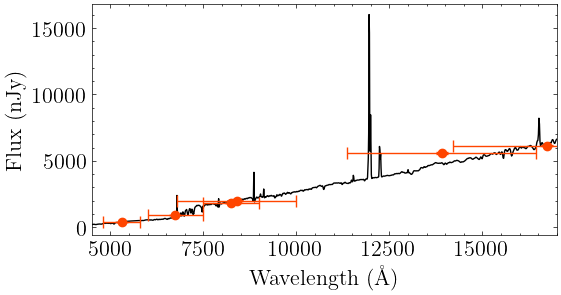

In [1057]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1058]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [1059]:
np.round(Mstar_KC,1)

10.0

In [1060]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [1061]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.57, -19.77, 10.4)

### Q24

In [1062]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [1063]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r
muse_pseudo_i


In [1064]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

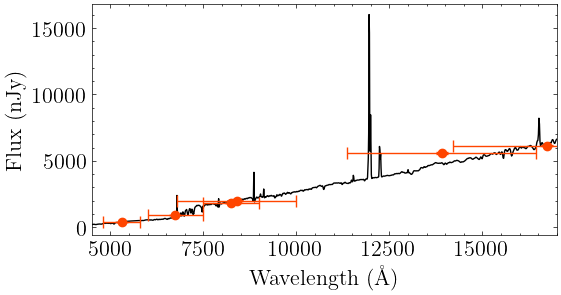

In [1065]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [1066]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [1067]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.61, 1.1, 10.2)

## z=1.0959

In [209]:
redshift = 1.0959
ebv = 0.0397

In [210]:
MUSE_mags = np.array([26.44, 26.23, 25.76])
dMUSE_mags = np.array([0.01, 0.01, 0.02])

HST_mags = np.array([25.533,23.742,23.388])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [211]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [212]:
np.abs(responses_out_lams.T*(1+redshift)-responses_lams)

array([[7759.5529, 6309.5529, 4809.5529, 4919.5529,  940.4471, 2940.4471],
       [4697.443 , 3247.443 , 1747.443 , 1857.443 , 4002.557 , 6002.557 ]])

In [213]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

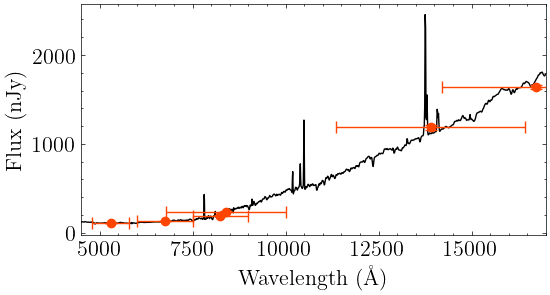

In [214]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [215]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [216]:
np.round(Mstar_KC,1)

10.0

In [217]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [218]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.65, -18.65, 10.0)

### Q24

In [219]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [220]:
np.abs(responses_out_lams.T*(1+redshift)-responses_lams)

array([[4131.55  , 2681.55  , 1181.55  , 1291.55  , 4568.45  , 6568.45  ],
       [2125.7737,  675.7737,  824.2263,  714.2263, 6574.2263, 8574.2263],
       [4697.443 , 3247.443 , 1747.443 , 1857.443 , 4002.557 , 6002.557 ]])

In [221]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

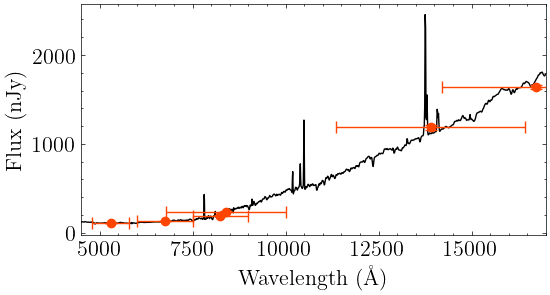

In [222]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [223]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [224]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.37, 1.04, 9.8)

## z=1.2256

In [225]:
redshift = 1.2256
ebv = 0.0397

In [234]:
MUSE_mags = np.array([25.879, 25.234, 24.655])
dMUSE_mags = np.array([0.007, 0.004, 0.006])

HST_mags = np.array([24.765,23.675,23.105])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [235]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [236]:
np.abs(responses_out_lams.T*(1+redshift)-responses_lams)

array([[8567.7136, 7117.7136, 5617.7136, 5727.7136,  132.2864, 2132.2864],
       [5316.112 , 3866.112 , 2366.112 , 2476.112 , 3383.888 , 5383.888 ]])

In [237]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

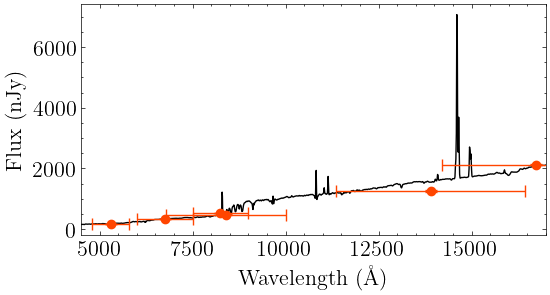

In [238]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [239]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [240]:
np.round(Mstar_KC,1)

9.9

In [241]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [242]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.14, -19.98, 9.3)

### Q24

In [243]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [244]:
np.abs(responses_out_lams.T*(1+redshift)-responses_lams)

array([[4715.2   , 3265.2   , 1765.2   , 1875.2   , 3984.8   , 5984.8   ],
       [2585.3008, 1135.3008,  364.6992,  254.6992, 6114.6992, 8114.6992],
       [5316.112 , 3866.112 , 2366.112 , 2476.112 , 3383.888 , 5383.888 ]])

In [245]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

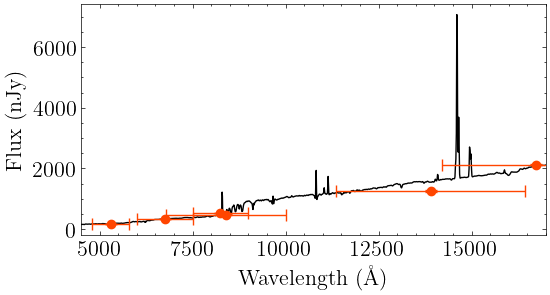

In [246]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [247]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [248]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.85, 0.99, 10.3)

## z=1.2787

In [250]:
redshift = 1.2787
ebv = 0.0397

In [251]:
MUSE_mags = np.array([26.45, 25.299, 24.26])
dMUSE_mags = np.array([0.01, 0.005, 0.005])

HST_mags = np.array([24.031,22.043,22.006])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [252]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [253]:
np.abs(responses_out_lams.T*(1+redshift)-responses_lams)

array([[8898.5797, 7448.5797, 5948.5797, 6058.5797,  198.5797, 1801.4203],
       [5569.399 , 4119.399 , 2619.399 , 2729.399 , 3130.601 , 5130.601 ]])

In [254]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

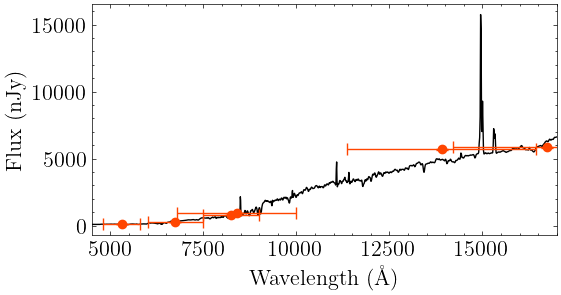

In [255]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [256]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [257]:
np.round(Mstar_KC,1)

10.7

In [258]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [259]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.89, -21.09, 10.9)

### Q24

In [260]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [261]:
np.abs(responses_out_lams.T*(1+redshift)-responses_lams)

array([[4954.15  , 3504.15  , 2004.15  , 2114.15  , 3745.85  , 5745.85  ],
       [2773.4341, 1323.4341,  176.5659,   66.5659, 5926.5659, 7926.5659],
       [5569.399 , 4119.399 , 2619.399 , 2729.399 , 3130.601 , 5130.601 ]])

In [262]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

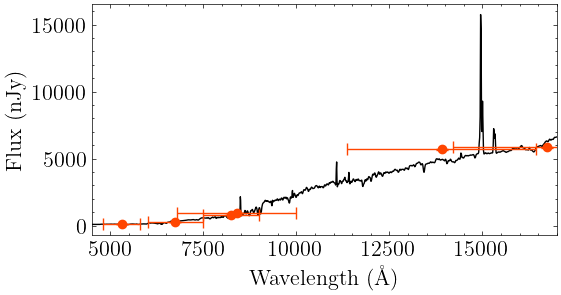

In [263]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [264]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [265]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.84, 1.18, 10.8)

# DRAFT

In [41]:
def compute_phot_err(mag, filt):
    
    '''
    mags: list of AB magnitudes
    '''
    
    F_nu_Jy = 3631*10**(-0.4*mag) # In Jy

    count_rate = F_nu_Jy/PHOTFNU_dict[filt] # Divide by sensitivity
    counts = count_rate*t_exp_dict[filt] # Get counts

    counts_err = np.sqrt(counts) # Get count error assuming Poisson counting
    count_rate_err = counts_err/t_exp_dict[filt] # Divide counts by exposure time
    dF_nu_Jy = count_rate_err*PHOTFNU_dict[filt] # Get error in F_nu

    # Compute error in magnitude using propagation of error
    dmag = np.abs((-2.5/np.log(10))*(dF_nu_Jy/F_nu_Jy))    

    return np.round(dmag,3)

In [42]:
pg_mags = np.array([25.683,26.415,25.945,26.446])
#pg_mags -= np.array([0.131,0.129,0.129,0.131])
dpg_mags = np.array([0.006,0.011,0.008,0.012])

pr_mags = np.array([24.147,26.204,25.405,25.299])
#pr_mags -= np.array([0.099,0.097,0.097,0.099])
dpr_mags = np.array([0.002,0.010,0.005,0.005])

pi_mags = np.array([23.800,25.714,24.852,24.260])
#pi_mags -= np.array([0.071,0.070,0.070,0.071])
dpi_mags = np.array([0.003,0.017,0.008,0.005])

In [43]:
pg_mags[0], dpg_mags[0]

(25.683, 0.006)

In [44]:
pr_mags[0], dpr_mags[0]

(24.147, 0.002)

In [45]:
pi_mags[0], dpi_mags[0]

(23.8, 0.003)

In [46]:
F814W_mags = np.array([23.634,25.533,24.765,24.031])
#F814W_mags -= np.array([0.070,0.069,0.069,0.070])
dF814W_mags = [compute_phot_err(mag,'F814W') for mag in F814W_mags]

F140W_mags = np.array([22.137,23.341,22.894,22.134])
#F140W_mags -= np.array([0.030,0.030,0.030,0.030])
dF140W_mags = [compute_phot_err(mag,'F140W') for mag in F140W_mags]

F160W_mags = np.array([21.989,23.178,22.693,22.049])
#F160W_mags -= np.array([0.022,0.022,0.022,0.022])
dF160W_mags = [compute_phot_err(mag,'F160W') for mag in F160W_mags]

In [47]:
dF140W_mags, dF160W_mags, dF814W_mags

([0.006, 0.011, 0.009, 0.006],
 [0.012, 0.02, 0.016, 0.012],
 [0.016, 0.039, 0.027, 0.019])

In [48]:
redshift = np.array([0.6780, 1.0959, 1.2256, 1.2787])

mags = np.zeros((4,6))
dmags = np.zeros((4,6))

mags[:,0] = pg_mags
dmags[:,0] = dpg_mags

mags[:,1] = pr_mags
dmags[:,1] = dpr_mags

mags[:,2] = pi_mags
dmags[:,2] = dpi_mags

mags[:,3] = F814W_mags
dmags[:,3] = dF814W_mags

mags[:,4] = F140W_mags
dmags[:,4] = dF140W_mags

mags[:,5] = F160W_mags
dmags[:,5] = dF160W_mags

In [52]:
mags

array([[25.683, 24.147, 23.8  , 23.634, 22.137, 21.989],
       [26.415, 26.204, 25.714, 25.533, 23.341, 23.178],
       [25.945, 25.405, 24.852, 24.765, 22.894, 22.693],
       [26.446, 25.299, 24.26 , 24.031, 22.134, 22.049]])

In [50]:
#dmags = 0.6*np.ones((4,3))

In [51]:
dmags

array([[0.006, 0.002, 0.003, 0.016, 0.006, 0.012],
       [0.011, 0.01 , 0.017, 0.039, 0.011, 0.02 ],
       [0.008, 0.005, 0.008, 0.027, 0.009, 0.016],
       [0.012, 0.005, 0.005, 0.019, 0.006, 0.012]])

In [53]:
df = pd.DataFrame()

In [55]:
df['z'] = redshift

In [57]:
df['pseudo-g'] = pg_mags
df['pseudo-r'] = pr_mags
df['pseudo-i'] = pi_mags
df['F814W'] = F814W_mags
df['F140W'] = F140W_mags
df['F160W'] = F160W_mags


In [58]:
df

,z,pseudo-g,pseudo-r,pseudo-i,F814W,F140W,F160W
0,0.6780,25.683,24.147,23.800,23.634,22.137,21.989
1,1.0959,26.415,26.204,25.714,25.533,23.341,23.178
2,1.2256,25.945,25.405,24.852,24.765,22.894,22.693
3,1.2787,26.446,25.299,24.260,24.031,22.134,22.049


# Bandpass filter wavelengths

In [112]:
#wavs_pass_min = np.array([11370.0,14210.0,6800.0,4800,6000,7500])
#wavs_pass_max = np.array([16450.0,19240.0,10000.0,5800,7500,9000])

wavs_pass_min = np.array([4800,6000,7500,6800,11370,14210])
wavs_pass_max = np.array([5800,7500,9000,10000,16450,19240])

wavs_pass_cen = .5*(wavs_pass_max+wavs_pass_min)
dwavs_pass = .5*(wavs_pass_max-wavs_pass_min)

In [113]:
wavs_pass_cen

array([ 5300.,  6750.,  8250.,  8400., 13910., 16725.])

# Fit

In [114]:
def get_maggies(m):
    # Maggies
    mu = 10**(-0.4*m)
    return mu

In [115]:
def get_ivar_maggies(mu, dm):
    dmu = np.abs(-0.4*np.log(10)*dm*mu)
    # Inverse variance for maggies
    return dmu**-2

In [116]:
maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

In [117]:
maggies

array([[6.01450652e-11, 2.40325580e-10, 3.22403687e-10, 3.75318524e-10,
        1.43615065e-09, 1.63380417e-09],
       [3.05914456e-11, 3.60744734e-11, 5.52586156e-11, 6.52228842e-11,
        4.73805393e-10, 5.46512375e-10],
       [4.71628455e-11, 7.53008711e-11, 1.22236245e-10, 1.32312233e-10,
        7.15154705e-10, 8.54279530e-10],
       [2.97851643e-11, 8.31763771e-11, 2.11057116e-10, 2.60375430e-10,
        1.44012437e-09, 1.54596622e-09]])

In [118]:
ivar

array([[9.05203322e+24, 5.10256621e+24, 1.26010325e+24, 3.26895299e+22,
        1.58761846e+22, 3.06680490e+21],
       [1.04103006e+25, 9.05834046e+24, 1.33582878e+24, 2.02416165e+23,
        4.33973559e+22, 9.86707998e+21],
       [8.28073079e+24, 8.31588799e+24, 1.23273199e+24, 9.96097715e+22,
        2.84553296e+22, 6.30969947e+21],
       [9.22754449e+24, 6.81567120e+24, 1.05854331e+24, 4.81660950e+22,
        1.57886915e+22, 3.42520168e+21]])

In [129]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [130]:
responses_out_lams*(1+1)

array([[9000, 7086, 9540]])

In [132]:
np.abs(responses_out_lams.T*(1+1)-responses_lams)

array([[3700, 2250,  750,  860, 5000, 7000],
       [1786,  336, 1164, 1054, 6914, 8914],
       [4240, 2790, 1290, 1400, 4460, 6460]])

In [133]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0',  'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

# "coeffs" is a [4,6]-array coefficients multiplying each template
coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

# "k" is a [3]-array with the K-corrections in magnitude units,
# from iri to Bug
k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

# "absmag" is also a [3]-array resuling from applying K-corrections
# and the distance modulus
absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

# Stellar mass estimates

In [134]:
MB = absmag[:,0]
ug = absmag[:,1]-absmag[:,2]

In [135]:
np.round(MB,2), np.round(ug,2)

(array([-18.48, -18.47, -19.86, -20.85], dtype=float32),
 array([1.  , 1.13, 1.2 , 1.51], dtype=float32))

In [136]:
def get_Mstar(MB, ug):
    
    logM_star_blue = -0.36*MB + 2.17*ug + 1.1
    logM_star_red = -0.36*MB + 0.72*ug + 2.4
    
    idx = ug>=0.9
    
    logM_star = logM_star_blue.copy()
    
    logM_star[idx] = logM_star_red[idx]
    
    return logM_star

In [137]:
np.round(get_Mstar(MB, ug), 1)

array([ 9.8,  9.9, 10.4, 11. ], dtype=float32)

# Assess fit

Text(0.5, 1.0, '$z_\\mathrm{gal}=0.6780, \\ \\log M_*/M_\\odot = 7.9$')

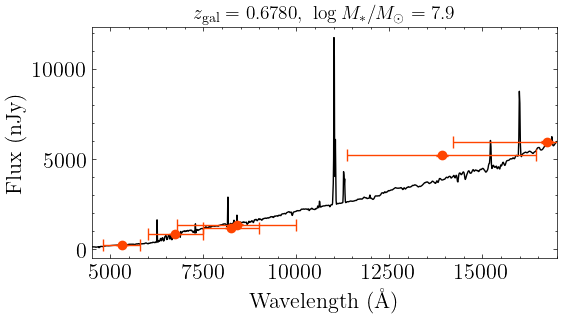

In [78]:
n = 0

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)
ax.set_title(r'$z_\mathrm{gal}=0.6780, \ \log M_*/M_\odot = 7.9$', fontsize=14)

Text(0.5, 1.0, '$z_\\mathrm{gal}=1.0959, \\ \\log M_*/M_\\odot = 8.1$')

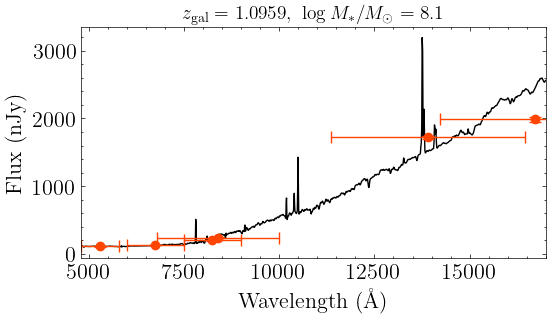

In [79]:
n = 1

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4800)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4800,17000)
ax.set_title(r'$z_\mathrm{gal}=1.0959, \ \log M_*/M_\odot = 8.1$', fontsize=14)

Text(0.5, 1.0, '$z_\\mathrm{gal}=1.2256, \\ \\log M_*/M_\\odot = 8.5$')

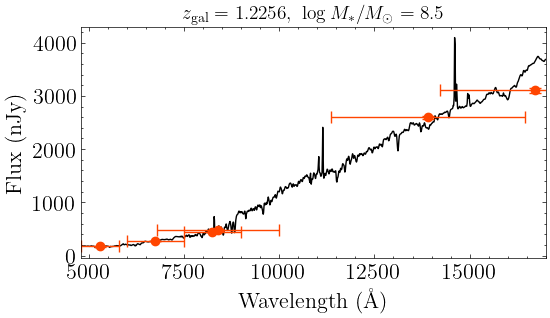

In [80]:
n = 2

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4800)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4800,17000)
ax.set_title(r'$z_\mathrm{gal}=1.2256, \ \log M_*/M_\odot = 8.5$', fontsize=14)

Text(0.5, 1.0, '$z_\\mathrm{gal}=1.2787, \\ \\log M_*/M_\\odot = 8.7$')

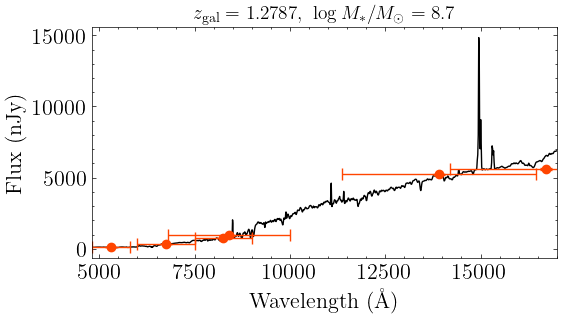

In [81]:
n = 3

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4800)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4800,17000)
ax.set_title(r'$z_\mathrm{gal}=1.2787, \ \log M_*/M_\odot = 8.7$', fontsize=14)

# Select galaxies

In [105]:
redshift = np.array([#0.6780, 
                     #1.0959, 
                     #1.2256, 
                     1.2787,
                    ])

        # pseudo-g psuedo-r pseudo-i F814W F140W F160W
mags = np.array([
       #[25.8905696, 24.673364 , 24.4225636], #23.5323008, 20.6465592, 20.7507296], # z=0.67
       #[26.2763076, 26.100659 , 25.6345591,], #25.4552748, 22.5160102, 22.7950176], # z=1.09
       #[25.8070028, 25.302177 , 24.7729573,],# 24.6876644, 21.5651906, 21.5981328], # z=1.22
       [26.3055696, 25.194364 , 24.1795636,], #23.9523008, 20.7265592, 20.9007296], # z=1.27
        ])

dmags = np.array([
       #[0.008, 0.003, 0.006]#, 0.015, 0.003, 0.007],
       #[0.011, 0.01 , 0.017,],# 0.037, 0.008, 0.017],
       #[0.008, 0.005, 0.008,],# 0.026, 0.005, 0.010],
       [0.012, 0.005, 0.005,], # 0.019, 0.003, 0.007],
        ])

In [92]:
mags = np.zeros((4,6))
dmags = np.zeros((4,6))

mags[:,0] = pg_mags
dmags[:,0] = dpg_mags

mags[:,1] = pr_mags
dmags[:,1] = dpr_mags

mags[:,2] = pi_mags
dmags[:,2] = dpi_mags

mags[:,3] = F814W_mags
dmags[:,3] = dF814W_mags

mags[:,4] = F140W_mags
dmags[:,4] = dF140W_mags

mags[:,5] = F160W_mags
dmags[:,5] = dF160W_mags

In [93]:
maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

In [94]:
#wavs_pass_min = np.array([11370.0,14210.0,6800.0,4800,6000,7500])
#wavs_pass_max = np.array([16450.0,19240.0,10000.0,5800,7500,9000])

wavs_pass_min = np.array([4800,6000,7500,6800,11370,14210])
wavs_pass_max = np.array([5800,7500,9000,10000,16450,19240])

wavs_pass_cen = .5*(wavs_pass_max+wavs_pass_min)
dwavs_pass = .5*(wavs_pass_max-wavs_pass_min)

Text(0.5, 1.0, '$z_\\mathrm{gal}=1.2256$')

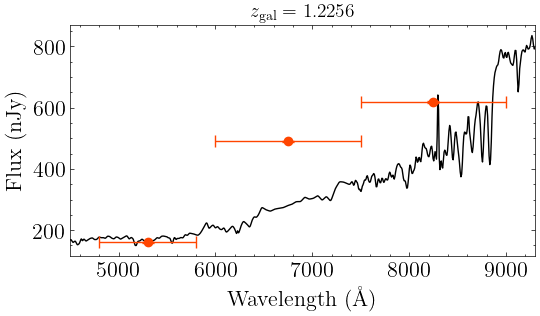

In [103]:
n = 0

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4500)&(wave<=9300)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[0:3], 1e9*3631*maggies[n,:][0:3], 
            xerr=dwavs_pass[0:3], yerr=1e9*3631*np.sqrt(ivar[n,:]**-1)[0:3],
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,9300)
ax.set_title(r'$z_\mathrm{gal}=1.2256$', fontsize=14)